# DAT494, Lab 1: CNNs + CAM/Grad-CAM

Overall lab outline:


### Part 1: Basic CNNs

- Get some training data and validation data (using the STL10 dataset) and apply basic data augmentations
- Implement a "Tiny ResNet" and train


### Part 2: CAM + GradCAM

- CAM on Tiny ResNet
- Grad-CAM on a Tiny ResNet variation


### Part 3: Simple Transfer Learning (+ Optional CAM/Grad-CAM)

- Get ResNet-18 for CNN backbone
- Replace classification head and fine tune
- Optional: Implement CAM and Grad-CAM for XAI on this model


### Part 4: MobileNetV3

- Implement MobileNetV3 from scratch
- Train MobileNetV3 on the STL10 Dataset



## Part 1: Basic CNNs:

In the first section of the lab, we implement and train a basic CNN classification model: "Tiny ResNet."

#### Get a simple image dataset to start

The very first thing we'll need is a simple image dataset: We can use the STL10 dataset, available through Torchvision (similar to the CIFAR10 dataset, but different classes and larger input images at 96x96).

Use the provided cells to download the training set, and split 500 observations off as a validation set. Note that we then wrap the training set in another Dataset (`TrainDataset`) to add a random horizontal flip, rotation, and color jitter.


In [2]:
#Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

#PyTorch Libraries
import torch
import torch.nn as nn
import torchvision

import torchvision.transforms.v2 as transforms

from torch.utils.data import Dataset, DataLoader

# Set device to GPU if available, otherwise CPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [3]:
## Basic transforms for the dataset
transform = transforms.Compose([transforms.ToImage(), transforms.ToDtype(torch.float32, scale=True)])

trainset = torchvision.datasets.STL10(root='./', split='train', #folds=0,
                                        download=True, transform=transform)

#We'll omit the testset
#testset = torchvision.datasets.STL10(root='./', split='test',
#                                       download=True, transform=transform)

100%|██████████| 2.64G/2.64G [05:38<00:00, 7.80MB/s]


In [4]:
from torch.utils.data import Subset

#Save last 500 for validation:
indices1 = range(0, 4500, 1)
indices2 = range(4500, 5000, 1)

stl10_train = Subset(trainset, indices1)
stl10_valid = Subset(trainset, indices2)

In [5]:
## Wrap the Train subset in a Dataset as follows,
## so we can add horizontal flip, random brightness change, and a random rotation:

class TrainDataset(Dataset):

    def __init__(self, base_set):

        self.set = base_set

        #Add these transforms
        self.transform = transforms.Compose([
            transforms.RandomHorizontalFlip(),
            transforms.ColorJitter(brightness=[.75,1.25]),
            transforms.RandomRotation(20),
        ])

    def __len__(self):
        return len(self.set)


    #Return transformed data and label
    def __getitem__(self, index):
        img, label = self.set[index] # self.set[index] yields (image_tensor, label)
        augmented_img = self.transform(img)
        return augmented_img, label # Return both augmented image and its label


In [6]:
## Make the modified trainset:
modified_trainset = TrainDataset(stl10_train)


In [7]:
#Also save the class names:

class_names = trainset.classes
class_names

['airplane',
 'bird',
 'car',
 'cat',
 'deer',
 'dog',
 'horse',
 'monkey',
 'ship',
 'truck']

#### Create DataLoaders and plot some examples

Create appropriate train and validation DataLoaders. Confirm that everything is in order by plotting a batch from the train set (and include class names).

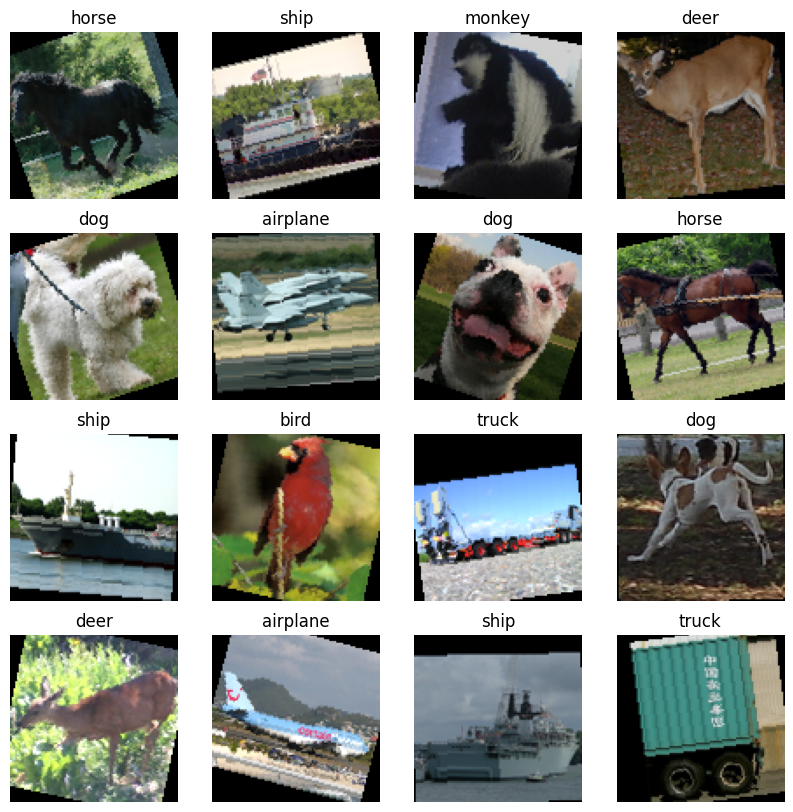

In [8]:
train_loader = DataLoader(modified_trainset, batch_size = 16, shuffle = True, num_workers=2, pin_memory=True)
valid_loader = DataLoader(stl10_valid, batch_size = 16, shuffle = True, num_workers=2, pin_memory=True)

pics, labels = next(iter(train_loader))

plt.figure(figsize=(10, 10))
for i in range(16):
    ax = plt
    plt.subplot(4, 4, i + 1)
    plt.imshow(pics[i].permute(1, 2, 0))
    plt.title(class_names[labels[i]])
    plt.axis("off")

#### Tiny ResNet model

First, implement a `ResidualBlock` with the following structure

```
class ResidualBlock(nn.Module):
    
    def __init__(self, in_channels, out_channels, stride=1):
        ...
        
    def forward(self, x):
        ...
```

1. 3x3 convolution with indicated stride and padding = 1
2. Batch normalization
3. ReLU activation
4. 3x3 convolution with "same" padding
5. Batch normalization
6. Skip connection
7. ReLU activation

- When `in_channels = out_channels` and `stride=1`, the skip connection simply entails adding the orginal input to the tensor that passed through Steps 1-5.

- Otherwise, the original input should pass through a bypass 1x1 convolution with appropriate `in_channels`, `out_channels`, and `stride` before being added in the skip connection.

In [17]:
class ResidualBlock(nn.Module):
  def __init__(self, in_channels, out_channels, stride = 1):
    super(ResidualBlock, self).__init__()
    self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size = 3, stride = stride, padding = 1)
    self.bn1 = nn.BatchNorm2d(out_channels)
    self.relu = nn.ReLU()
    self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size = 3, stride = 1, padding = 1)
    self.bn2 = nn.BatchNorm2d(out_channels)
    self.skip = nn.Sequential()
    if in_channels == out_channels and stride == 1:
      self.skip = nn.Identity()
    else:
      self.skip = nn.Conv2d(in_channels, out_channels, kernel_size = 1, stride = stride)

  def forward(self, x):
    out = self.conv1(x)
    out = self.bn1(out)
    out = self.relu(out)
    out = self.conv2(out)
    out = self.bn2(out)
    out += self.skip(x)
    out = self.relu(out)
    return out

#### TinyResNet

And now implment a model, called `TinyResNet`, with the following structure:

1. (Input)
2. 7x7 Conv, **Stride 2**, Same padding; 8 channels
3. BatchNorm; ReLU Activation
4. 2x2 Pooling Layer, **Stride 2**

<br>

4. ResidualBlock, **Stride 2**, 16 channels out
5. ResidualBlock, **Stride 2**, 32 channels out

<br>

6. **Global Average Pooling**
7. Linear Layer, 32 inputs, 10 outputs


In [18]:
class TinyResNet(nn.Module):
  def __init__(self):
    super(TinyResNet, self).__init__()
    self.conv1 = nn.Conv2d(3, 8, kernel_size = 7, stride = 2, padding = 3)
    self.bn1 = nn.BatchNorm2d(8)
    self.relu = nn.ReLU()
    self.pool = nn.MaxPool2d(kernel_size = 2, stride = 2)
    self.resblock1 = ResidualBlock(8, 16, stride = 2)
    self.resblock2 = ResidualBlock(16, 32, stride = 2)
    self.avgpool = nn.AdaptiveAvgPool2d((1, 1))
    self.fc = nn.Linear(32, 10)

  def forward(self, x):
    x = self.conv1(x)
    x = self.bn1(x)
    x = self.relu(x)
    x = self.pool(x)
    x = self.resblock1(x)
    x = self.resblock2(x)
    x = self.avgpool(x)
    x = x.view(x.size(0), -1)
    x = self.fc(x)
    return x

#### Train the model

- Using an appropriate loss function, optimizer, helper functions, etc.,  train the model for multiple epochs. Track performance on the testing and validation dataset each epoch.

- Train the model until performance on the validation set appears to plateau (just visually is fine), and **plot** train/validation accuracy as a function of epoch.


Epoch 1/30 - Train Loss: 1.9345, Train Acc: 0.2656, Valid Loss: 1.8024, Valid Acc: 0.2920
Epoch 2/30 - Train Loss: 1.7020, Train Acc: 0.3424, Valid Loss: 1.7643, Valid Acc: 0.3340
Epoch 3/30 - Train Loss: 1.6222, Train Acc: 0.3820, Valid Loss: 2.2106, Valid Acc: 0.2180
Epoch 4/30 - Train Loss: 1.5565, Train Acc: 0.4104, Valid Loss: 1.9340, Valid Acc: 0.3560
Epoch 5/30 - Train Loss: 1.5109, Train Acc: 0.4327, Valid Loss: 1.4912, Valid Acc: 0.4300
Epoch 6/30 - Train Loss: 1.4605, Train Acc: 0.4431, Valid Loss: 1.4327, Valid Acc: 0.4560
Epoch 7/30 - Train Loss: 1.4256, Train Acc: 0.4722, Valid Loss: 1.4852, Valid Acc: 0.4320
Epoch 8/30 - Train Loss: 1.4011, Train Acc: 0.4787, Valid Loss: 1.4481, Valid Acc: 0.4460
Epoch 9/30 - Train Loss: 1.3676, Train Acc: 0.4953, Valid Loss: 1.2927, Valid Acc: 0.5040
Epoch 10/30 - Train Loss: 1.3346, Train Acc: 0.4991, Valid Loss: 1.3645, Valid Acc: 0.5100
Epoch 11/30 - Train Loss: 1.3199, Train Acc: 0.5091, Valid Loss: 1.2773, Valid Acc: 0.5100
Epoch 12

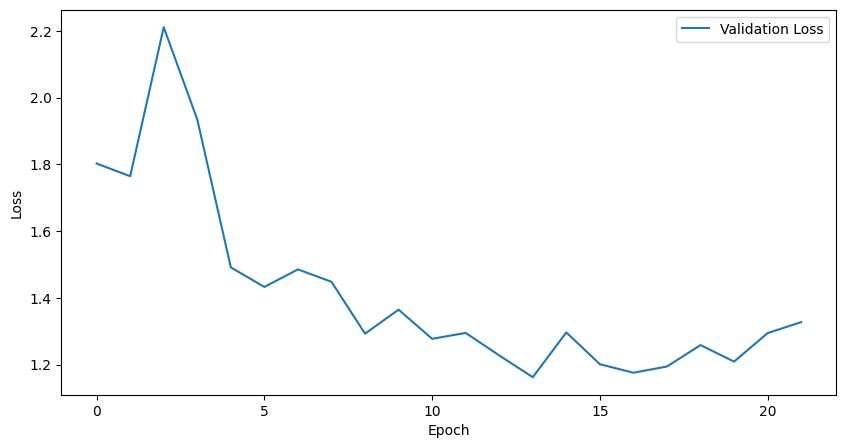

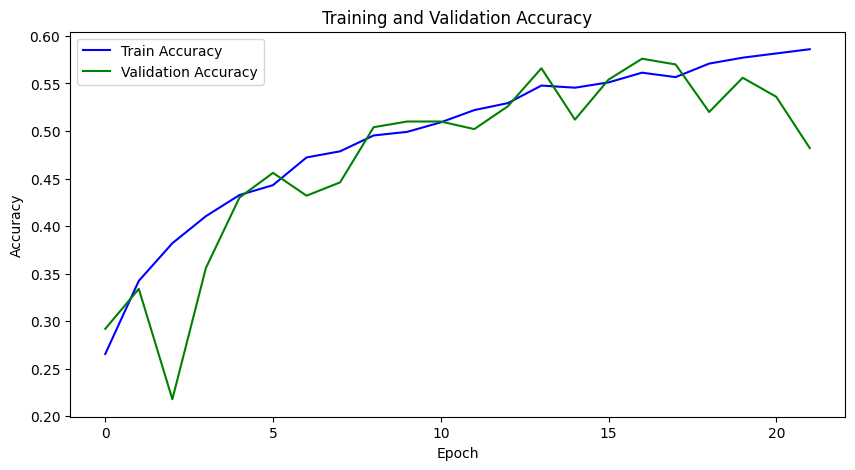

In [19]:
model = TinyResNet().to(device)
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr = 0.001)

def train(model, train_loader, optimizer, loss_fn):
  model.train()
  total_loss = 0
  correct = 0
  for batch, (X, buffer) in enumerate(train_loader):
    X, buffer = X.to(device), buffer.to(device)
    optimizer.zero_grad()
    pred = model(X)
    loss = loss_fn(pred, buffer)
    loss.backward()
    optimizer.step()
    total_loss += loss.item()
    correct += (pred.argmax(1) ==buffer).type(torch.float).sum().item()
  train_accuracy = correct / len(train_loader.dataset)
  return total_loss / len(train_loader), train_accuracy

def test(model, test_loader, loss_fn):
  model.eval()
  test_loss = 0
  correct = 0
  with torch.no_grad():
    for X, buffer in test_loader:
      X, buffer = X.to(device), buffer.to(device)
      pred = model(X)
      test_loss += loss_fn(pred, buffer).item()
      correct += (pred.argmax(1) ==buffer).type(torch.float).sum().item()
  test_loss /= len(test_loader)
  accuracy = correct / len(test_loader.dataset)
  return test_loss, accuracy

train_losses = []
valid_losses = []
train_accuracies = []
valid_accuracies = []
epochs = 30

best_valid_acc = -1.0
epochs_no_improve = 0
patience = 5

# Used Generative AI to implement early stopping mechanism in training

for epoch in range(epochs):
    train_loss_epoch, train_acc_epoch = train(model, train_loader, optimizer, loss_fn)
    valid_loss_epoch, valid_acc_epoch = test(model, valid_loader, loss_fn)
    train_losses.append(train_loss_epoch)
    valid_losses.append(valid_loss_epoch)
    train_accuracies.append(train_acc_epoch)
    valid_accuracies.append(valid_acc_epoch)
    print(f"Epoch {epoch+1}/{epochs} - Train Loss: {train_loss_epoch:.4f}, Train Acc: {train_acc_epoch:.4f}, Valid Loss: {valid_loss_epoch:.4f}, Valid Acc: {valid_acc_epoch:.4f}")

    if valid_acc_epoch > best_valid_acc:
        best_valid_acc = valid_acc_epoch
        epochs_no_improve = 0
    else:
        epochs_no_improve += 1
        if epochs_no_improve == patience:
            print(f"Early stopping triggered after {patience} epochs without improvement.")
            break

plt.figure(figsize=(10, 5))
plt.plot(valid_losses, label = 'Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

plt.figure(figsize = (10, 5))
plt.plot(train_accuracies, label = 'Train Accuracy', color = 'blue')
plt.plot(valid_accuracies, label = 'Validation Accuracy', color = 'green')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training and Validation Accuracy')
plt.legend()
plt.show()

## Part 2: CAM + GradCAM

Here we implement:

- CAM on Tiny ResNet
- Grad-CAM and Grad-CAM on a Tiny ResNet variation

#### Implement CAM and visualize

- Calculate Class Activation Maps (CAMs), and visualize the CAM for the model-predicted class for several example inputs
- Include a couple examples where the model predicted the correct class, as well as a couple misclassifications

Examples classified correctly:


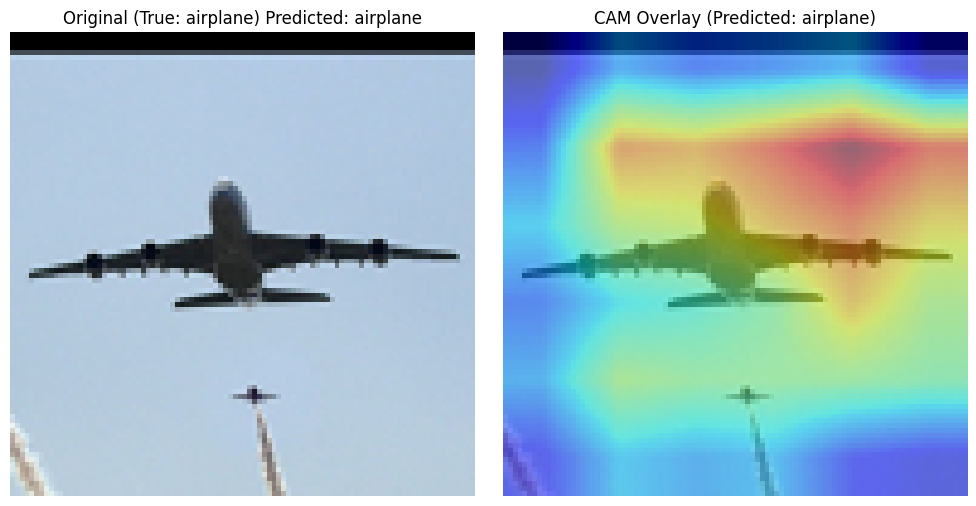

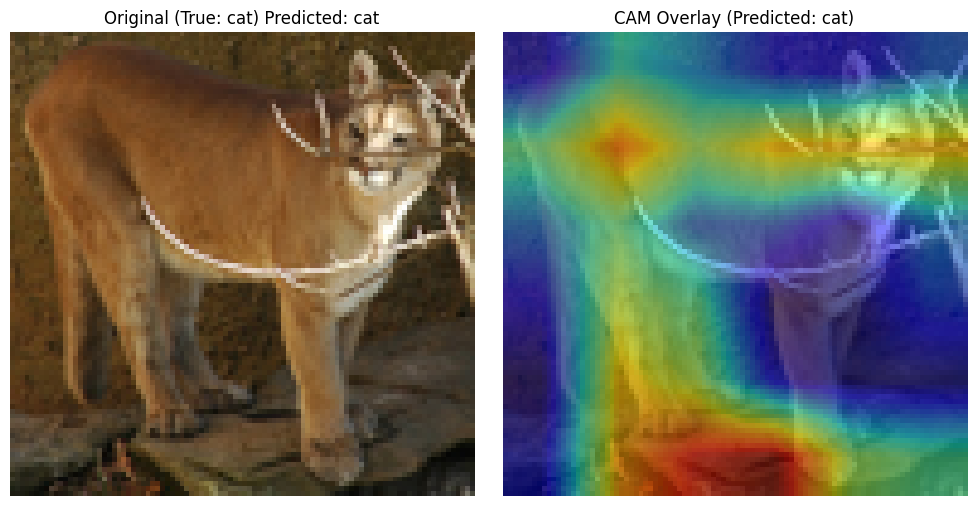

Examples classified incorrectly:


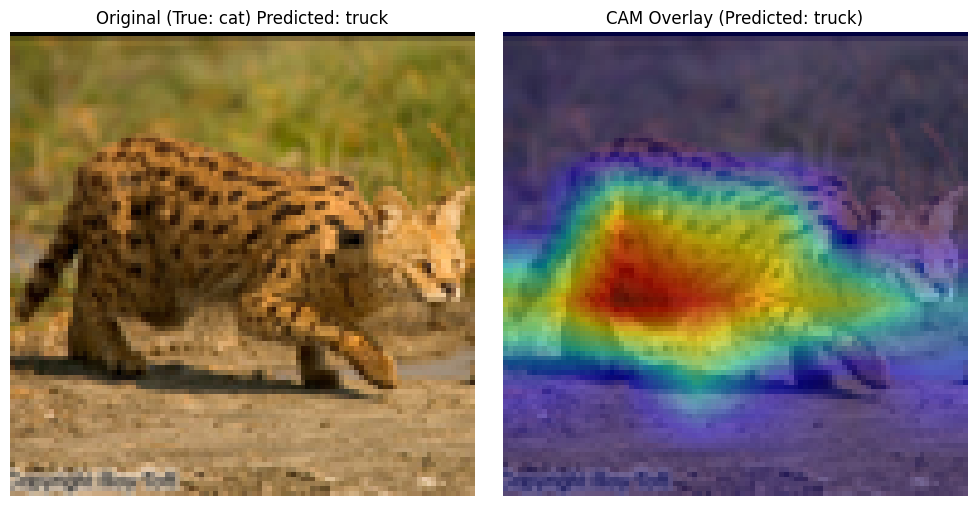

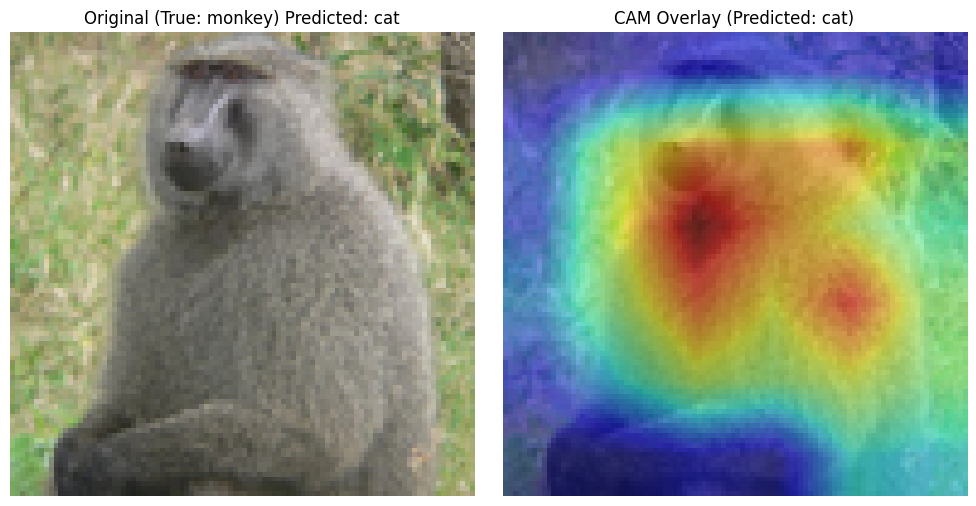

In [21]:
import cv2

feature_maps = None
def hook_fn(module, input, output):
    global feature_maps
    feature_maps = output

handler = model.resblock2.register_forward_hook(hook_fn)

def generate_cam(model, image, predicted_class, class_names):
    model.eval()
    image = image.to(device)
    logits = model(image.unsqueeze(0))
    weights = model.fc.weight.data

    class_weights = weights[predicted_class]

    cam = torch.einsum('c,chw->hw', class_weights, feature_maps.squeeze(0))
    cam = torch.relu(cam)
    cam = cam - cam.min()
    cam = cam / cam.max()

    h, w = image.shape[1], image.shape[2]
    cam_resized = cv2.resize(cam.cpu().detach().numpy(), (w, h))

    return cam_resized, logits

# Used Generative AI to assist in the creation of the visualize_cam function and the visualization of classified/misclassified examples

def visualize_cam(original_image, cam, predicted_class_idx, true_class_idx, class_names, title="CAM"):
    fig, axes = plt.subplots(1, 2, figsize=(10, 5))

    axes[0].imshow(original_image.permute(1, 2, 0).cpu().numpy())
    axes[0].set_title(f"Original (True: {class_names[true_class_idx]}) Predicted: {class_names[predicted_class_idx]}")
    axes[0].axis('off')

    axes[1].imshow(original_image.permute(1, 2, 0).cpu().numpy())
    axes[1].imshow(cam, cmap='jet', alpha=0.5)
    axes[1].set_title(f"CAM Overlay (Predicted: {class_names[predicted_class_idx]})")
    axes[1].axis('off')
    plt.tight_layout()
    plt.show()

model.eval()
num_examples = 4
correct_examples = []
misclassified_examples = []

with torch.no_grad():
    for images, labels in valid_loader:
        for idx in range(len(images)):
            image = images[idx]
            true_label = labels[idx]

            output = model(image.unsqueeze(0).to(device))
            predicted_label = output.argmax(1).item()

            if predicted_label  == true_label:
                if len(correct_examples) < num_examples / 2:
                    correct_examples.append((image, predicted_label, true_label))
            else:
                if len(misclassified_examples) < num_examples / 2:
                    misclassified_examples.append((image, predicted_label, true_label))

            if len(correct_examples) + len(misclassified_examples) >= num_examples:
                break
        if len(correct_examples) + len(misclassified_examples) >= num_examples:
            break

print("Examples classified correctly:")
for img, pred_idx, true_idx in correct_examples:
    cam, _ = generate_cam(model, img, pred_idx, class_names)
    visualize_cam(img, cam, pred_idx, true_idx, class_names)

print("Examples classified incorrectly:")
for img, pred_idx, true_idx in misclassified_examples:
    cam, _ = generate_cam(model, img, pred_idx, class_names)
    visualize_cam(img, cam, pred_idx, true_idx, class_names)

handler.remove()

#### Implement Grad-CAM and visualize

First, let's create a modified model:

- Create a modified version of TinyResNet: Replace the Global Average Pooling Layer and final FC layer with a single FC layer with appropriate dimensions
- Fine-tune this model on the training data: Freeze all layers except your new FC layer, and train as appropriate
- Confirm acceptable performance on the validation dataset

Second:

- Implement Grad-CAM and calculate the "class discriminative localization map" for the final set of feature maps before the output layer, and for the model-predicted class
- As before, include a couple examples where the model predicted the correct class, as well as a couple misclassifications

Epoch 1/10 - Train Loss: 2.0288, Train Acc: 0.2676, Valid Loss: 1.9414, Valid Acc: 0.2860
Epoch 2/10 - Train Loss: 1.8442, Train Acc: 0.3424, Valid Loss: 1.8938, Valid Acc: 0.3040
Epoch 3/10 - Train Loss: 1.7711, Train Acc: 0.3664, Valid Loss: 1.8297, Valid Acc: 0.3420
Epoch 4/10 - Train Loss: 1.7619, Train Acc: 0.3729, Valid Loss: 1.7066, Valid Acc: 0.3840
Epoch 5/10 - Train Loss: 1.7198, Train Acc: 0.3824, Valid Loss: 1.7343, Valid Acc: 0.3900
Epoch 6/10 - Train Loss: 1.7054, Train Acc: 0.3940, Valid Loss: 1.8543, Valid Acc: 0.3380
Epoch 7/10 - Train Loss: 1.6954, Train Acc: 0.3911, Valid Loss: 1.7941, Valid Acc: 0.3680
Epoch 8/10 - Train Loss: 1.6983, Train Acc: 0.3922, Valid Loss: 1.7630, Valid Acc: 0.3600
Early stopping triggered for GradCAM model after 3 epochs without improvement.


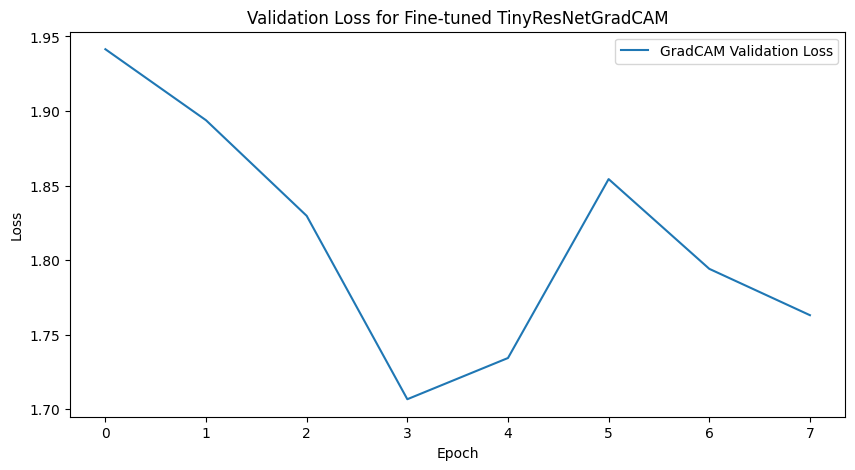

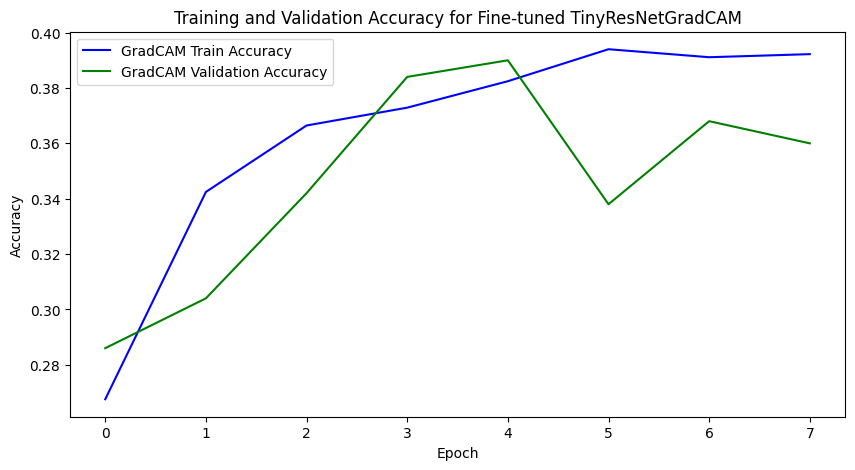


Examples classified correctly:


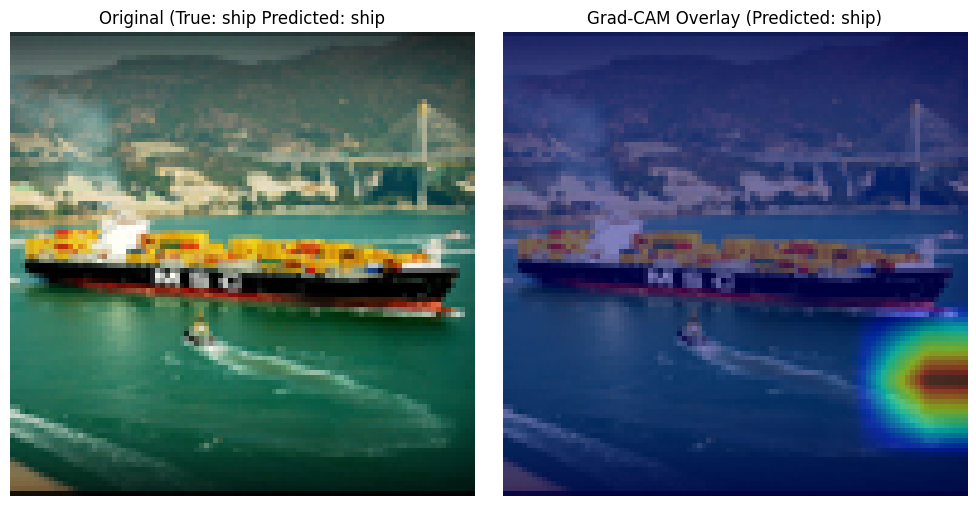

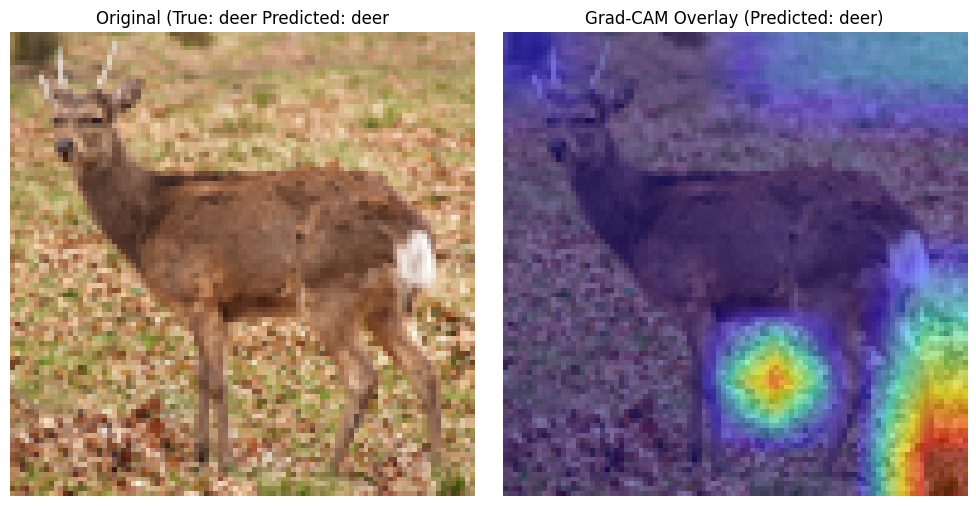


Examples classified incorrectly:


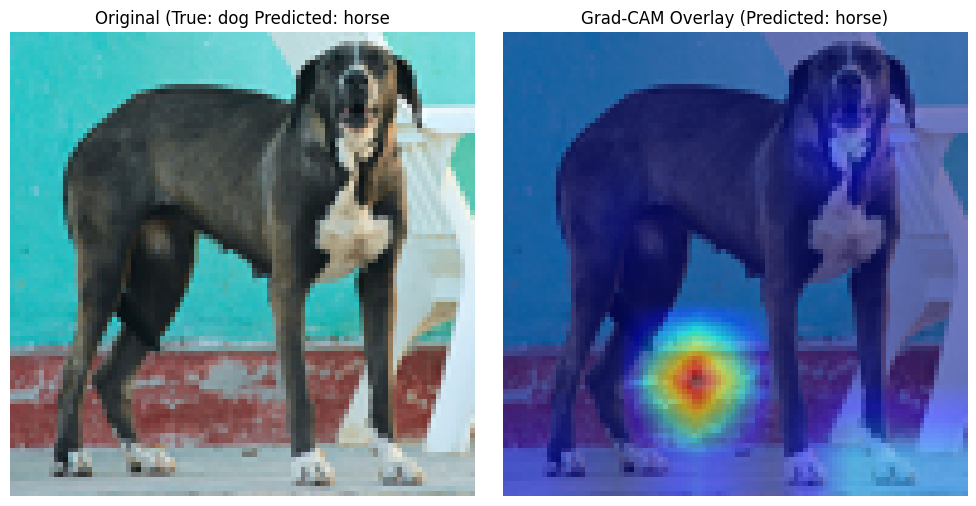

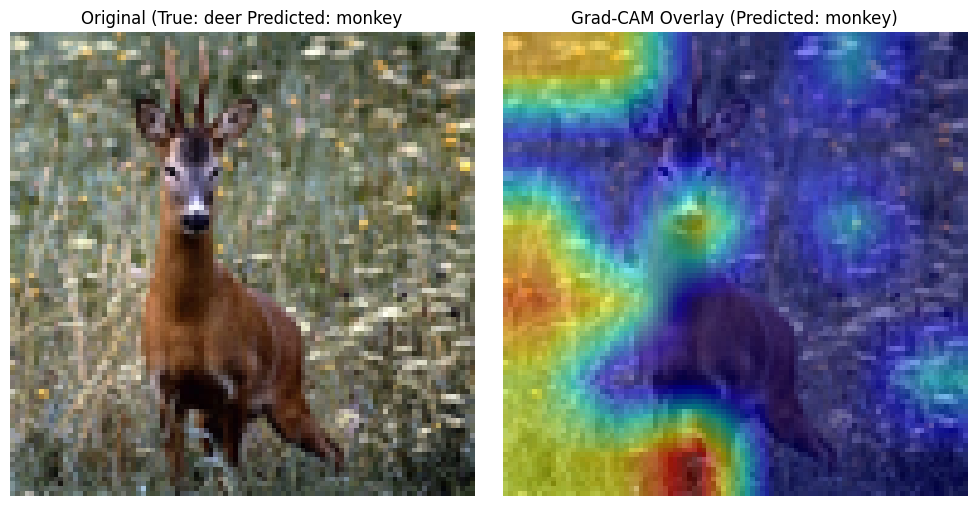

In [22]:
import cv2

class TinyResNetGradCAM(nn.Module):
    def __init__(self):
        super(TinyResNetGradCAM, self).__init__()
        self.conv1 = nn.Conv2d(3, 8, kernel_size=7, stride=2, padding=3)
        self.bn1 = nn.BatchNorm2d(8)
        self.relu = nn.ReLU()
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)
        self.resblock1 = ResidualBlock(8, 16, stride=2)
        self.resblock2 = ResidualBlock(16, 32, stride=2)
        self.new_fc = nn.Linear(32 * 6 * 6, 10)

    def forward(self, data):
        data = self.conv1(data)
        data = self.bn1(data)
        data = self.relu(data)
        data = self.pool(data)
        data = self.resblock1(data)
        data = self.resblock2(data)
        data = data.view(data.size(0), -1)
        data = self.new_fc(data)
        return data

# Used Generative AI to help implement the training for the tweaked TinyResNet model

model_gradcam = TinyResNetGradCAM().to(device) # Move model to device

for name, param in model_gradcam.named_parameters():
    if "new_fc" not in name:
        param.requires_grad = False
    else:
        param.requires_grad = True

loss_fn_gradcam = nn.CrossEntropyLoss()
optimizer_gradcam = torch.optim.Adam(filter(lambda p: p.requires_grad, model_gradcam.parameters()), lr=0.001)

gradcam_train_losses = []
gradcam_valid_losses = []
gradcam_train_accuracies = []
gradcam_valid_accuracies = []
epochs_gradcam = 10

best_valid_acc_gradcam = -1.0
epochs_no_improve_gradcam = 0
patience_gradcam = 3

for epoch in range(epochs_gradcam):
    train_loss_epoch, train_acc_epoch = train(model_gradcam, train_loader, optimizer_gradcam, loss_fn_gradcam)
    valid_loss_epoch, valid_acc_epoch = test(model_gradcam, valid_loader, loss_fn_gradcam)
    gradcam_train_losses.append(train_loss_epoch)
    gradcam_valid_losses.append(valid_loss_epoch)
    gradcam_train_accuracies.append(train_acc_epoch)
    gradcam_valid_accuracies.append(valid_acc_epoch)
    print(f"Epoch {epoch+1}/{epochs_gradcam} - Train Loss: {train_loss_epoch:.4f}, Train Acc: {train_acc_epoch:.4f}, Valid Loss: {valid_loss_epoch:.4f}, Valid Acc: {valid_acc_epoch:.4f}")

    if valid_acc_epoch > best_valid_acc_gradcam:
        best_valid_acc_gradcam = valid_acc_epoch
        epochs_no_improve_gradcam = 0
    else:
        epochs_no_improve_gradcam += 1
        if epochs_no_improve_gradcam == patience_gradcam:
            print(f"Early stopping triggered for GradCAM model after {patience_gradcam} epochs without improvement.")
            break

plt.figure(figsize=(10, 5))
plt.plot(gradcam_valid_losses, label='GradCAM Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.title('Validation Loss for Fine-tuned TinyResNetGradCAM')
plt.show()

plt.figure(figsize=(10, 5))
plt.plot(gradcam_train_accuracies, label='GradCAM Train Accuracy', color='blue')
plt.plot(gradcam_valid_accuracies, label='GradCAM Validation Accuracy', color='green')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training and Validation Accuracy for Fine-tuned TinyResNetGradCAM')
plt.legend()
plt.show()

class GradCAM:
    def __init__(self, model, target_layer):
        self.model = model
        self.target_layer = target_layer
        self.activations = None
        self.gradients = None
        self.model.eval()
        self._register_hooks()

    def _register_hooks(self):
        def forward_hook(module, input, output):
            self.activations = output
        def backward_hook(module, grad_in, grad_out):
            self.gradients = grad_out[0]

        self.target_layer.register_forward_hook(forward_hook)
        self.target_layer.register_full_backward_hook(backward_hook)

    def generate_cam(self, input_image, target_class=None):
        self.model.zero_grad()
        input_image.requires_grad_(True)
        output = self.model(input_image)

        if target_class is None:
            target_class = output.argmax(dim=1).item()

        one_hot_output = torch.zeros_like(output)
        one_hot_output[0][target_class] = 1

        output.backward(gradient=one_hot_output, retain_graph=True)
        gradients = self.gradients
        activations = self.activations

        weights = torch.mean(gradients, dim=(2, 3), keepdim=True)
        cam = (weights * activations).sum(dim=1, keepdim=True)
        cam = torch.relu(cam)

        cam = cam - cam.min()
        if cam.max() > 0:
            cam = cam / cam.max()
        else:
            cam = torch.zeros_like(cam)

        return cam.squeeze().cpu().detach().numpy()

target_layer = model_gradcam.resblock2
grad_cam_instance = GradCAM(model_gradcam, target_layer)

# Used generative AI to help modify the visualize grad cam function and display the correctly/incorrectly classified images

def visualize_grad_cam(original_image, cam, predicted_class_idx, true_class_idx, class_names, title="Grad-CAM"):
    fig, axes = plt.subplots(1, 2, figsize=(10, 5))

    axes[0].imshow(original_image.permute(1, 2, 0).cpu().numpy())
    axes[0].set_title(f"Original (True: {class_names[true_class_idx]} Predicted: {class_names[predicted_class_idx]}")
    axes[0].axis('off')

    axes[1].imshow(original_image.permute(1, 2, 0).cpu().numpy())
    h, w = original_image.shape[1], original_image.shape[2]
    cam_resized = cv2.resize(cam, (w, h), interpolation=cv2.INTER_LINEAR)
    axes[1].imshow(cam_resized, cmap='jet', alpha=0.5)
    axes[1].set_title(f"{title} Overlay (Predicted: {class_names[predicted_class_idx]})")
    axes[1].axis('off')
    plt.tight_layout()
    plt.show()

num_examples_to_show = 4
correct_examples_gradcam = []
misclassified_examples_gradcam = []

model_gradcam.eval()

with torch.no_grad():
    for images, labels in valid_loader:
        for idx in range(len(images)):
            image = images[idx].unsqueeze(0).to(device)
            true_label = labels[idx].item()

            output = model_gradcam(image)
            predicted_label = output.argmax(1).item()

            if predicted_label == true_label:
                if len(correct_examples_gradcam) < num_examples_to_show / 2:
                    correct_examples_gradcam.append((images[idx], predicted_label, true_label))
            else:
                if len(misclassified_examples_gradcam) < num_examples_to_show / 2:
                    misclassified_examples_gradcam.append((images[idx], predicted_label, true_label))

            if len(correct_examples_gradcam) + len(misclassified_examples_gradcam) >= num_examples_to_show:
                break
        if len(correct_examples_gradcam) + len(misclassified_examples_gradcam) >= num_examples_to_show:
            break

print("\nExamples classified correctly:")
for img, pred_idx, true_idx in correct_examples_gradcam:
    cam_grad = grad_cam_instance.generate_cam(img.unsqueeze(0).to(device), pred_idx) # Move img to device
    visualize_grad_cam(img, cam_grad, pred_idx, true_idx, class_names)

print("\nExamples classified incorrectly:")
for img, pred_idx, true_idx in misclassified_examples_gradcam:
    cam_grad = grad_cam_instance.generate_cam(img.unsqueeze(0).to(device), pred_idx) # Move img to device
    visualize_grad_cam(img, cam_grad, pred_idx, true_idx, class_names)

## Part 3: Simple Transfer Learning + CAM/Grad-CAM

Goals for Part 3:

#### Part 3A: Implement and Fine-Tune the Model:

- Use torchvision to get **ResNet-18** for your CNN backbone
- Don't forget to get the weights and the input data transform (and be sure to apply the input transform to your input data)
- Make a new model that uses ResNet-18 for the backbone, but replace the final classification head with a fully connected layer with 512 inputs (number of pooled feature maps) and 10 outputs
- Fine-tune the model on the STL10 training set used above: **Train only the weights for your final fully connected layer**
- Train for an appropriate number of epochs, and report training and validation accuracy over these epochs
- Visualize several model predictions: Show the input image and predicted class probabilities


#### Optional Part 3B: CAM

- Optionally, using the model developed in Part A, implement CAM and visualize the class activation maps for the predicted class, along with the input image, for several example inputs


#### Optional Part 3C:  Grad-CAM

- Again, optionally, implement Grad-CAM and similarly visualize class activation maps (for the final convolutional feature maps) for a few example inputs



### Part 3A: Transfer Learning with ResNet-18

As above, your tasks follow. Use as many cells, etc. as needed. Provide a brief summary of the final model architecture and performance

- Use torchvision to get **ResNet-18** for your CNN backbone
- Don't forget to get the weights and the input data transform (and be sure to apply the input transform to your input data)
- Make a new model that uses ResNet-18 for the backbone, but replace the final classification head with a fully connected layer with 512 inputs (number of pooled feature maps) and 10 outputs
- Fine-tune the model on the STL10 training set used above: **Train only the weights for your final fully connected layer**
- Train for an appropriate number of epochs, and report training and validation accuracy over these epochs
- Visualize several model predictions: Show the input image and predicted class probabilities


Epoch 1/10 - Train Loss: 0.9553, Train Acc: 0.7198, Valid Loss: 0.3557, Valid Acc: 0.9020
Epoch 2/10 - Train Loss: 0.5202, Train Acc: 0.8384, Valid Loss: 0.2903, Valid Acc: 0.9000
Epoch 3/10 - Train Loss: 0.4798, Train Acc: 0.8360, Valid Loss: 0.2701, Valid Acc: 0.9160
Epoch 4/10 - Train Loss: 0.4115, Train Acc: 0.8631, Valid Loss: 0.2334, Valid Acc: 0.9100
Epoch 5/10 - Train Loss: 0.4225, Train Acc: 0.8569, Valid Loss: 0.2518, Valid Acc: 0.9120
Epoch 6/10 - Train Loss: 0.4068, Train Acc: 0.8567, Valid Loss: 0.2181, Valid Acc: 0.9160
Early stopping triggered for ResNet-18 fine-tuning after 3 epochs without improvement.


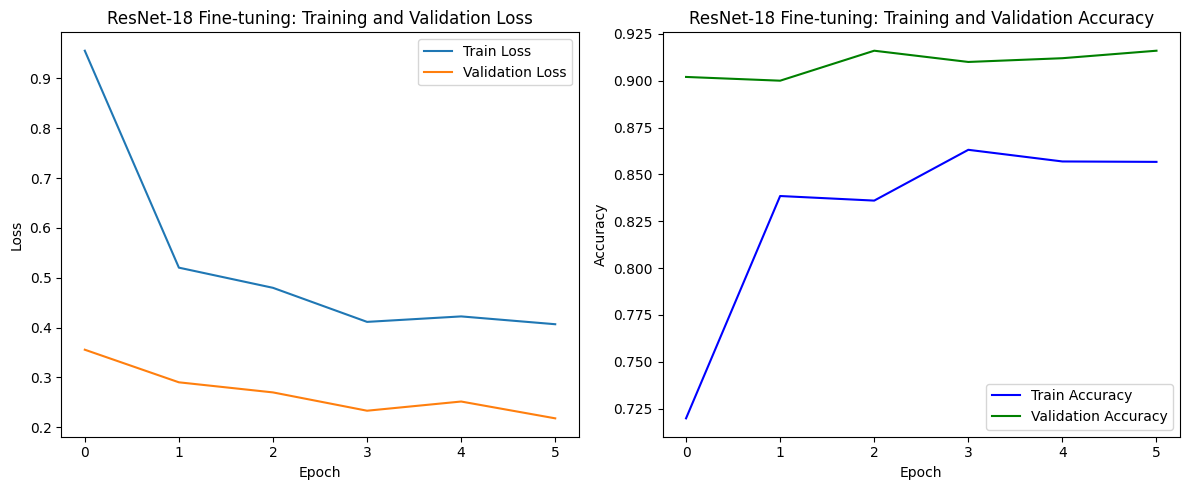


ResNet-18 predictions:


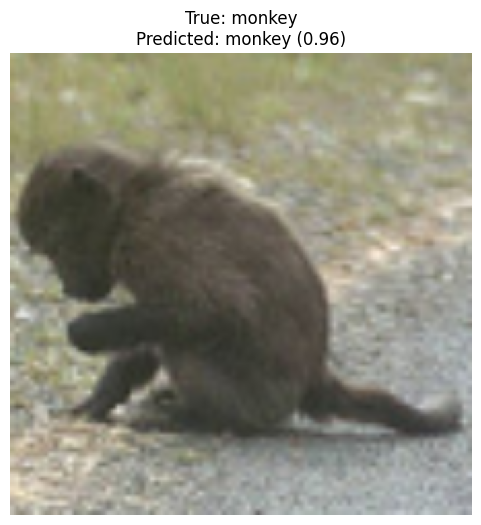

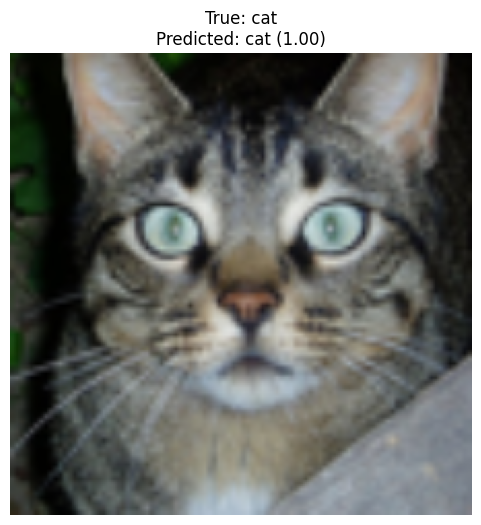

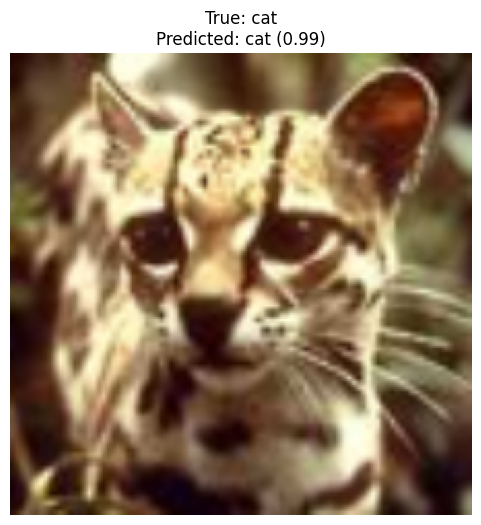

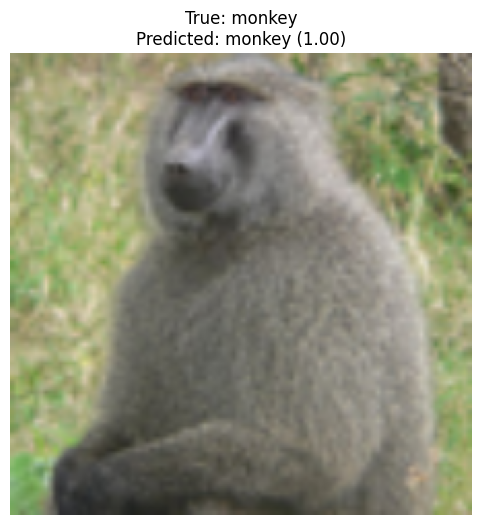

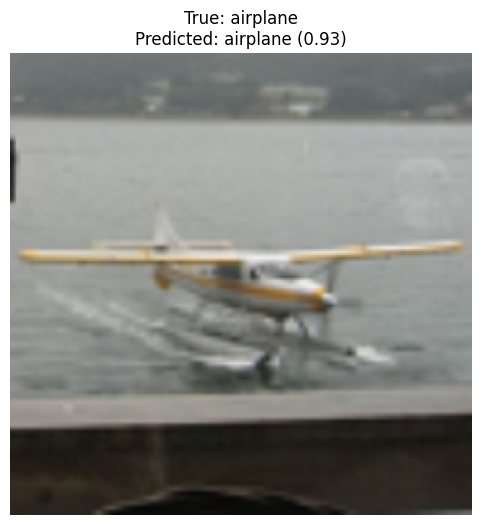

In [28]:
import torchvision.models as models
import torchvision.transforms.v2 as T

model_resnet = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1).to(device)

transform_resnet = models.ResNet18_Weights.IMAGENET1K_V1.transforms()

num_ftrs = model_resnet.fc.in_features
model_resnet.fc = nn.Linear(num_ftrs, len(class_names))
model_resnet = model_resnet.to(device)

for name, param in model_resnet.named_parameters():
    if "fc" not in name:
        param.requires_grad = False
    else:
        param.requires_grad = True


transform_finetune = T.Compose([
    T.Resize(224),
    T.Normalize(mean=transform_resnet.mean, std=transform_resnet.std)
])

# Used generative AI to create the model using ResNet-18 as the foundation and used it to fine tune
# the model as well as display correctly/incorrectly classified images

class ResnetTrainDataset(Dataset):
    def __init__(self, base_augmented_set, transform_finetune):
        self.base_augmented_set = base_augmented_set
        self.transform = transform_finetune

    def __len__(self):
        return len(self.base_augmented_set)

    def __getitem__(self, index):
        augmented_img, label = self.base_augmented_set[index]
        transformed_img = self.transform(augmented_img)
        return transformed_img, label

class ResnetValidDataset(Dataset):
    def __init__(self, base_set, transform_finetune):
        self.set = base_set
        self.transform = transform_finetune

    def __len__(self):
        return len(self.set)

    def __getitem__(self, index):
        img, label = self.set[index]
        transformed_img = self.transform(img)
        return transformed_img, label


resnet_train_dataset = ResnetTrainDataset(modified_trainset, transform_finetune)
resnet_valid_dataset = ResnetValidDataset(stl10_valid, transform_finetune)

resnet_train_loader = DataLoader(resnet_train_dataset, batch_size=16, shuffle=True, num_workers=2, pin_memory=True)
resnet_valid_loader = DataLoader(resnet_valid_dataset, batch_size=16, shuffle=False, num_workers=2, pin_memory=True)

loss_fn_resnet = nn.CrossEntropyLoss()
optimizer_resnet = torch.optim.Adam(filter(lambda p: p.requires_grad, model_resnet.parameters()), lr=0.001)

train_losses_resnet = []
valid_losses_resnet = []
train_accuracies_resnet = []
valid_accuracies_resnet = []
epochs_resnet = 10

best_valid_acc_resnet = -1.0
epochs_no_improve_resnet = 0
patience_resnet = 3

for epoch in range(epochs_resnet):
    train_loss_epoch, train_acc_epoch = train(model_resnet, resnet_train_loader, optimizer_resnet, loss_fn_resnet)
    valid_loss_epoch, valid_acc_epoch = test(model_resnet, resnet_valid_loader, loss_fn_resnet)
    train_losses_resnet.append(train_loss_epoch)
    valid_losses_resnet.append(valid_loss_epoch)
    train_accuracies_resnet.append(train_acc_epoch)
    valid_accuracies_resnet.append(valid_acc_epoch)
    print(f"Epoch {epoch+1}/{epochs_resnet} - Train Loss: {train_loss_epoch:.4f}, Train Acc: {train_acc_epoch:.4f}, Valid Loss: {valid_loss_epoch:.4f}, Valid Acc: {valid_acc_epoch:.4f}")

    if valid_acc_epoch > best_valid_acc_resnet:
        best_valid_acc_resnet = valid_acc_epoch
        epochs_no_improve_resnet = 0
    else:
        epochs_no_improve_resnet += 1
        if epochs_no_improve_resnet == patience_resnet:
            print(f"Early stopping triggered for ResNet-18 fine-tuning after {patience_resnet} epochs without improvement.")
            break

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(train_losses_resnet, label = 'Train Loss')
plt.plot(valid_losses_resnet, label = 'Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('ResNet-18 Fine-tuning: Training and Validation Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(train_accuracies_resnet, label = 'Train Accuracy', color = 'blue')
plt.plot(valid_accuracies_resnet, label = 'Validation Accuracy', color = 'green')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('ResNet-18 Fine-tuning: Training and Validation Accuracy')
plt.legend()
plt.tight_layout()
plt.show()

print("\nResNet-18 predictions:")
model_resnet.eval()
num_visualize = 5

with torch.no_grad():
    for i, (images, labels) in enumerate(resnet_valid_loader):
        if i >= num_visualize: break

        image = images[0].unsqueeze(0).to(device)
        true_label = labels[0].item()

        output = model_resnet(image)
        probabilities = torch.softmax(output, dim=1)[0]
        predicted_prob, predicted_idx = torch.max(probabilities, 0)

        plt.figure(figsize=(6, 6))
        mean = torch.tensor(transform_resnet.mean).view(3, 1, 1).to(device)
        std = torch.tensor(transform_resnet.std).view(3, 1, 1).to(device)
        display_image = image.squeeze(0) * std + mean
        display_image = torch.clamp(display_image, 0, 1)

        plt.imshow(display_image.permute(1, 2, 0).cpu().numpy())
        plt.title(f"True: {class_names[true_label]}\nPredicted: {class_names[predicted_idx.item()]} ({predicted_prob.item():.2f})")
        plt.axis('off')
        plt.show()

### Optional Part 3B: CAM

- Using the model developed in Part A, implement CAM and visualize the class activation maps for the predicted class, along with the input image, for several example inputs
- You can use a forward hook to save the relevant layer output (alternatively, you can create a modified model that returns/stores the relevant feature map activations)

### Optional Part 3C:  Grad-CAM

Do Grad-CAM on TinyResNet instead


- Again using ResNet-18 as a base, remove the global average pooling layer and connect the final feature map outputs to a fully connected layer with $512 \times 7 \times 7$ inputs, and 10 outputs
- Fine-tune this model
- Implement Grad-CAM, and similar to Part 3B, visualize class discriminative localization maps (for the final convolutional feature maps) for a few example inputs


## Part 4: MobileNetV3

- Implement MobileNetV3 from scratch
- Train MobileNetV3 on the STL10 dataset

Your first task is to implement all of the special activation functions and layers/blocks used in MobileNetV3. These include:

1. MyReLU6
2. Hard Sigmoid
3. Hard Swish
4. Squeeze-excitation block
5. Separable depthwise convolution
6. Residual inverted bottleneck with linear, with or without an incorporated squeeze-excitation block

Implement all, and test all on appropriate tensors inputs and confirm that they give expected behavior (or at least expected output dimensions).

In [24]:
import torch
import torch.nn as nn
import torch.nn.functional as F


class MyReLU6(nn.Module):
    def forward(self, x):
        out = F.relu6(x)
        return out


sample = torch.randn(1, 10, 24, 24)
relu6_mod = MyReLU6()
relu6_out = relu6_mod(sample)
print("MyReLU6 -> in:", sample.shape, "| out:", relu6_out.shape)


class MyHardSigmoid(nn.Module):
    def forward(self, x):
        shifted = x + 3
        clipped = F.relu6(shifted)
        return clipped / 6


sample = torch.randn(1, 10, 24, 24)
hsig = MyHardSigmoid()
hsig_out = hsig(sample)
print("HardSigmoid -> in:", sample.shape, "| out:", hsig_out.shape)


class MyHardSwish(nn.Module):
    def forward(self, x):
        scale = F.relu6(x + 3) / 6
        return x * scale


sample = torch.randn(1, 10, 24, 24)
hswish = MyHardSwish()
hswish_out = hswish(sample)
print("HardSwish -> in:", sample.shape, "| out:", hswish_out.shape)


class SimpleSE(nn.Module):
    def __init__(self, channels, squeeze_ratio=4):
        super().__init__()
        reduced = channels // squeeze_ratio
        self.reduce_conv = nn.Conv2d(channels, reduced, 1)
        self.expand_conv = nn.Conv2d(reduced, channels, 1)
        self.act = MyHardSigmoid()

    def forward(self, x):
        pooled = F.adaptive_avg_pool2d(x, 1)
        pooled = self.reduce_conv(pooled)
        pooled = F.relu(pooled)
        pooled = self.expand_conv(pooled)
        weights = self.act(pooled)
        return x * weights


sample = torch.randn(1, 32, 24, 24)
se_mod = SimpleSE(32)
se_out = se_mod(sample)
print("SqueezeExcitation -> in:", sample.shape, "| out:", se_out.shape)


class DepthwiseSeparableConv(nn.Module):
    def __init__(self, in_ch, out_ch, k_size, stride=1, pad=0):
        super().__init__()
        self.dw = nn.Conv2d(in_ch, in_ch, k_size, stride=stride, padding=pad, groups=in_ch)
        self.pw = nn.Conv2d(in_ch, out_ch, 1)

    def forward(self, x):
        x = self.dw(x)
        x = self.pw(x)
        return x


sample = torch.randn(1, 32, 24, 24)
sep_layer = DepthwiseSeparableConv(32, 64, 3, stride=1, pad=1)
sep_out = sep_layer(sample)
print("SeparableConv2d -> in:", sample.shape, "| out:", sep_out.shape)


class InvertedResBlock(nn.Module):
    def __init__(self, in_ch, hidden_ch, out_ch, k_size, stride, with_se, act_layer):
        super().__init__()

        self.use_skip = (stride == 1 and in_ch == out_ch)
        pad = (k_size - 1) // 2

        block_layers = []

        if in_ch != hidden_ch:
            block_layers.append(nn.Conv2d(in_ch, hidden_ch, 1, bias=False))
            block_layers.append(nn.BatchNorm2d(hidden_ch))
            block_layers.append(act_layer())

        block_layers.append(
            nn.Conv2d(hidden_ch, hidden_ch, k_size, stride=stride, padding=pad, groups=hidden_ch, bias=False)
        )
        block_layers.append(nn.BatchNorm2d(hidden_ch))
        block_layers.append(act_layer())

        if with_se:
            block_layers.append(SimpleSE(hidden_ch))

        block_layers.append(nn.Conv2d(hidden_ch, out_ch, 1, bias=False))
        block_layers.append(nn.BatchNorm2d(out_ch))

        self.block = nn.Sequential(*block_layers)

    def forward(self, x):
        if self.use_skip:
            return x + self.block(x)
        return self.block(x)


sample = torch.randn(1, 16, 24, 24)

block_a = InvertedResBlock(16, 64, 16, 3, 1, True, MyHardSwish)
out_a = block_a(sample)
print("IR Block 1 -> in:", sample.shape, "| out:", out_a.shape)

block_b = InvertedResBlock(16, 64, 32, 3, 2, False, MyReLU6)
out_b = block_b(sample)
print("IR Block 2 -> in:", sample.shape, "| out:", out_b.shape)

MyReLU6 -> in: torch.Size([1, 10, 24, 24]) | out: torch.Size([1, 10, 24, 24])
HardSigmoid -> in: torch.Size([1, 10, 24, 24]) | out: torch.Size([1, 10, 24, 24])
HardSwish -> in: torch.Size([1, 10, 24, 24]) | out: torch.Size([1, 10, 24, 24])
SqueezeExcitation -> in: torch.Size([1, 32, 24, 24]) | out: torch.Size([1, 32, 24, 24])
SeparableConv2d -> in: torch.Size([1, 32, 24, 24]) | out: torch.Size([1, 64, 24, 24])
IR Block 1 -> in: torch.Size([1, 16, 24, 24]) | out: torch.Size([1, 16, 24, 24])
IR Block 2 -> in: torch.Size([1, 16, 24, 24]) | out: torch.Size([1, 32, 12, 12])


#### Build the overall model

Consult the original paper for the structure of MobileNetV3-Small (Table 2 and related text). Implement the model and ensure that you can run the model given an image input of size 96x96 (note your final convolutional layer output will be 3x3 instead of 7x7).

- Howard, A., Sandler, M., Chu, G., Chen, L. C., Chen, B., Tan, M., ... & Adam, H. (2019). Searching for mobilenetv3. In Proceedings of the IEEE/CVF international conference on computer vision (pp. 1314-1324). https://arxiv.org/abs/1905.02244


In [25]:
class MobileNetV3Small(nn.Module):
  def __init__(self, num_classes=10):
        super(MobileNetV3Small, self).__init__()

        self.features = nn.Sequential(
            nn.Conv2d(3, 16, 3, 2, 1, bias = False),
            nn.BatchNorm2d(16),
            MyHardSwish(),
            InvertedResBlock(16, 16, 16, 3, 2, False, MyReLU6),
            InvertedResBlock(16, 72, 24, 3, 2, False, MyReLU6),
            InvertedResBlock(24, 88, 24, 3, 1, False, MyReLU6),
            InvertedResBlock(24, 96, 40, 5, 2, True, MyHardSwish),
            InvertedResBlock(40, 240, 40, 5, 1, True, MyHardSwish),
            InvertedResBlock(40, 120, 40, 5, 1, True, MyHardSwish),
            InvertedResBlock(40, 144, 48, 5, 1, True, MyHardSwish),
            InvertedResBlock(48, 288, 48, 5, 1, True, MyHardSwish),
            InvertedResBlock(48, 288, 96, 5, 2, True, MyHardSwish),
            InvertedResBlock(96, 576, 96, 5, 1, True, MyHardSwish),
            InvertedResBlock(96, 576, 96, 5, 1, True, MyHardSwish),
        )

        self.classifier = nn.Sequential(
            nn.Conv2d(96, 576, 1, 1, bias = False),
            nn.BatchNorm2d(576),
            MyHardSwish(),
            nn.AdaptiveAvgPool2d(1),
            nn.Conv2d(576, 1280, 1, 1, bias = False),
            MyHardSwish(),
            nn.Dropout(0.2),
            nn.Conv2d(1280, num_classes, 1, 1)
        )

  def forward(self, data):
      x = self.features(data)
      x = self.classifier(x)
      x = x.view(x.size(0), -1)
      return x

model_mobilenetv3 = MobileNetV3Small(num_classes=len(class_names))
dummy_input_mobilenetv3 = torch.randn(1, 3, 96, 96)
output_mobilenetv3 = model_mobilenetv3(dummy_input_mobilenetv3)

#### Train

Adapt or re-use your training code from above to train your MobileNetV3-Small clone at least until you've confirmed the model does significantly better than chance.

Briefly summarize model performance.

In [29]:
model_mobilenetv3 = MobileNetV3Small(num_classes=len(class_names)).to(device)
loss_fn_mobilenetv3 = nn.CrossEntropyLoss()
optimizer_mobilenetv3 = torch.optim.Adam(model_mobilenetv3.parameters(), lr=0.001)

mobilenetv3_train_losses = []
mobilenetv3_valid_losses = []
mobilenetv3_train_accuracies = []
mobilenetv3_valid_accuracies = []
epochs_mobilenetv3 = 30

most_valid_acc_mobilenetv3 = -1.0
epochs_no_improve_mobilenetv3 = 0
patience_mobilenetv3 = 5

chance_accuracy = 1.0 / len(class_names)
significant_threshold = chance_accuracy + 0.05

# Used generative AI to implement the significance check in the loop in order to ensure the
# model's performance exceeds mere chance and summarize model performance

for epoch in range(epochs_mobilenetv3):
    train_loss_epoch, train_acc_epoch = train(model_mobilenetv3, train_loader, optimizer_mobilenetv3, loss_fn_mobilenetv3)
    valid_loss_epoch, valid_acc_epoch = test(model_mobilenetv3, valid_loader, loss_fn_mobilenetv3)
    mobilenetv3_train_losses.append(train_loss_epoch)
    mobilenetv3_valid_losses.append(valid_loss_epoch)
    mobilenetv3_train_accuracies.append(train_acc_epoch)
    mobilenetv3_valid_accuracies.append(valid_acc_epoch)
    print(f"Epoch {epoch+1}/{epochs_mobilenetv3} - Train Loss: {train_loss_epoch:.4f}, Train Acc: {train_acc_epoch:.4f}, Valid Loss: {valid_loss_epoch:.4f}, Valid Acc: {valid_acc_epoch:.4f}")

    if valid_acc_epoch > most_valid_acc_mobilenetv3:
        most_valid_acc_mobilenetv3 = valid_acc_epoch
        epochs_no_improve_mobilenetv3 = 0
    else:
        epochs_no_improve_mobilenetv3 += 1

    if epochs_no_improve_mobilenetv3 >= patience_mobilenetv3:
        if most_valid_acc_mobilenetv3 > significant_threshold:
            print(f"Model achieved significant performance (best validation accuracy: {most_valid_acc_mobilenetv3:.4f}) before stopping.")
            break
        else:
            epochs_no_improve_mobilenetv3 = 0

final_train_acc = mobilenetv3_train_accuracies[-1] if mobilenetv3_train_accuracies else 0.0
final_valid_acc = mobilenetv3_valid_accuracies[-1] if mobilenetv3_valid_accuracies else 0.0

print("Model Performance - ")
print(f"Final Training Accuracy: {final_train_acc:.4f}")
print(f"Final Validation Accuracy: {final_valid_acc:.4f}")

Epoch 1/30 - Train Loss: 1.9948, Train Acc: 0.2200, Valid Loss: 1.8543, Valid Acc: 0.2800
Epoch 2/30 - Train Loss: 1.7578, Train Acc: 0.3036, Valid Loss: 1.6404, Valid Acc: 0.3300
Epoch 3/30 - Train Loss: 1.6729, Train Acc: 0.3702, Valid Loss: 1.5364, Valid Acc: 0.4000
Epoch 4/30 - Train Loss: 1.5767, Train Acc: 0.4007, Valid Loss: 1.5290, Valid Acc: 0.4080
Epoch 5/30 - Train Loss: 1.5001, Train Acc: 0.4407, Valid Loss: 1.4572, Valid Acc: 0.4420
Epoch 6/30 - Train Loss: 1.4467, Train Acc: 0.4696, Valid Loss: 1.3454, Valid Acc: 0.4620
Epoch 7/30 - Train Loss: 1.3764, Train Acc: 0.4953, Valid Loss: 1.4820, Valid Acc: 0.4640
Epoch 8/30 - Train Loss: 1.3338, Train Acc: 0.5080, Valid Loss: 1.3673, Valid Acc: 0.4900
Epoch 9/30 - Train Loss: 1.3037, Train Acc: 0.5262, Valid Loss: 1.2383, Valid Acc: 0.5380
Epoch 10/30 - Train Loss: 1.2587, Train Acc: 0.5431, Valid Loss: 1.2359, Valid Acc: 0.5500
Epoch 11/30 - Train Loss: 1.1995, Train Acc: 0.5618, Valid Loss: 1.2591, Valid Acc: 0.5380
Epoch 12